# NYC Yellow Cab Trip Analysis
## Course Assessment Notebook — Big Data Analytics & Text Mining (Module 2)

**Student:** Ibrahim Askar  
**ID:** 0001159181  
**Dataset:** NYC TLC Yellow Taxi Trip Records — January & February 2024  
**Platform:** Course VM (Ubuntu 22.04, OpenJDK 11, PySpark 3.5.3, Vagrant/VirtualBox) — 4 GB RAM, 2 vCPUs  

---

### Required Libraries

| Library | Version | Notes |
|---|---|---|
| Python | 3.10.12 | VM default |
| Java (OpenJDK) | 11.0.30 | VM pre-installed |
| PySpark | 3.5.3 | pip-installed in setup cell |
| findspark | 2.0.1+ | pip-installed in setup cell |
| pandas | 2.0+ | pip-installed |
| matplotlib | 3.7+ | pip-installed |
| seaborn | 0.12+ | pip-installed |
| numpy | 1.24+ | pip-installed |
| scikit-learn | 1.3+ | pip-installed (used in ROC curve plotting) |

> **Note on platform:** This project runs on the course VM (single-node PySpark deployment). Spark is used for scalable data processing and ML on ~5.97 million rows. Shuffle partitions are set to 50 and driver memory to 2 GB.

---

### Algorithms Covered
1. Exploratory Data Analysis (EDA)
2. K-Means Clustering — spatial/temporal trip pattern discovery
3. Random Forest Classifier — predict high-tip trips
4. Logistic Regression — baseline classifier comparison


---
## Section 0: Environment Setup

Install Java 17 and PySpark. This cell takes ~2 minutes on first run.

In [9]:
!pip install pyspark==3.5.3 findspark --quiet

In [10]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Course_IbrahimAskar_0001159181")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.ui.showConsoleProgress", "false")
    .config("spark.driver.extraJavaOptions", "--add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.nio.charset=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED")
    .config("spark.executor.extraJavaOptions", "--add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.nio.charset=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("OFF")
print(f"Spark {spark.version} ready")

Spark 3.5.3 ready


---
## Section 1: Data Loading

Download Yellow Cab Parquet files for January and February 2024 from the NYC TLC public dataset.  
Expected size: ~45–60 MB per file. Expected total rows: ~11 million.

In [11]:
# Download parquet files
!wget -q "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet" \
    -O /tmp/yellow_2024_01.parquet
!wget -q "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-02.parquet" \
    -O /tmp/yellow_2024_02.parquet
!ls -lh /tmp/yellow_*.parquet

-rw-rw-r-- 1 vagrant vagrant 48M Mar 21  2024 /tmp/yellow_2024_01.parquet
-rw-rw-r-- 1 vagrant vagrant 49M Apr 19  2024 /tmp/yellow_2024_02.parquet


In [12]:
# Load and union both months
df1 = spark.read.parquet("/tmp/yellow_2024_01.parquet")
df2 = spark.read.parquet("/tmp/yellow_2024_02.parquet")

# unionByName matches columns by name (safer than union if schema drifts slightly)
df_raw = df1.unionByName(df2, allowMissingColumns=True)

total_rows = df_raw.count()
print(f"Total rows: {total_rows:,}")
print(f"Columns: {len(df_raw.columns)}")
df_raw.printSchema()

Total rows: 5,972,150
Columns: 19
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [13]:
# Preview
df_raw.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|2       |2024-01-01 00:57:55 |2024-01-01 01:17:43  |1              |1.72         |1         |N                 |186         |79          |2           |17.7       |1.0  |0.5    |0.0      

---
## Section 2: Exploratory Data Analysis (EDA)

### 2.1 Descriptive Statistics

In [14]:
import pyspark.sql.functions as F

key_cols = ["fare_amount", "trip_distance", "tip_amount",
            "total_amount", "passenger_count", "tolls_amount"]

df_raw.select(key_cols).describe().show()

[Stage 19:===========================================>              (3 + 1) / 4]

+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|       fare_amount|     trip_distance|        tip_amount|      total_amount|   passenger_count|      tolls_amount|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|           5972150|           5972150|           5972150|           5972150|           5646378|           5972150|
|   mean|18.110719233445277|3.7572635583497678|3.3192375861293875|26.712322959068896|1.3326125172632792|0.5172431586601463|
| stddev|18.791680643398426|240.61659853792628| 3.862271267581612| 23.17853423589474| 0.841419586690241| 2.104543968148311|
|    min|            -999.0|               0.0|            -140.0|           -1000.0|                 0|             -80.0|
|    max|            9792.0|          312722.3|            543.33|            9792.0|                 9|            115.92|
+-------

> **Insight:** Fare and tip distributions are right-skewed: the majority of trips are short city hops with mean fare $18.11 and mean trip distance 3.76 miles, but long-tail airport and outer-borough rides pull the mean up. The mean tip of $3.32 (all payment types) informs the $2.00 classification threshold used for credit-card trips, which approximates the lower bound of a generous tip for short-to-medium rides.

### 2.2 Missing Value Analysis

In [15]:
n_total = total_rows  # already computed in data loading cell

null_counts = df_raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_raw.columns
])

import pandas as pd
null_pd = null_counts.toPandas().T.reset_index()
null_pd.columns = ["column", "null_count"]
null_pd["null_pct"] = (null_pd["null_count"] / n_total * 100).round(2)
null_pd = null_pd[null_pd["null_count"] > 0].sort_values("null_pct", ascending=False)
print(null_pd.to_string(index=False))

[Stage 22:=============================>                            (2 + 2) / 4]

              column  null_count  null_pct
     passenger_count      325772      5.45
          RatecodeID      325772      5.45
  store_and_fwd_flag      325772      5.45
congestion_surcharge      325772      5.45
         Airport_fee      325772      5.45


> **Insight:** The missing columns (passenger_count, RatecodeID, store_and_fwd_flag, congestion_surcharge, Airport_fee) are all optional fields that vendors may omit. The consistent 5.45% null rate (325,772 rows) across all five suggests these come from the same subset of vendor records, not random measurement errors.

### 2.3 Fare Amount Distribution

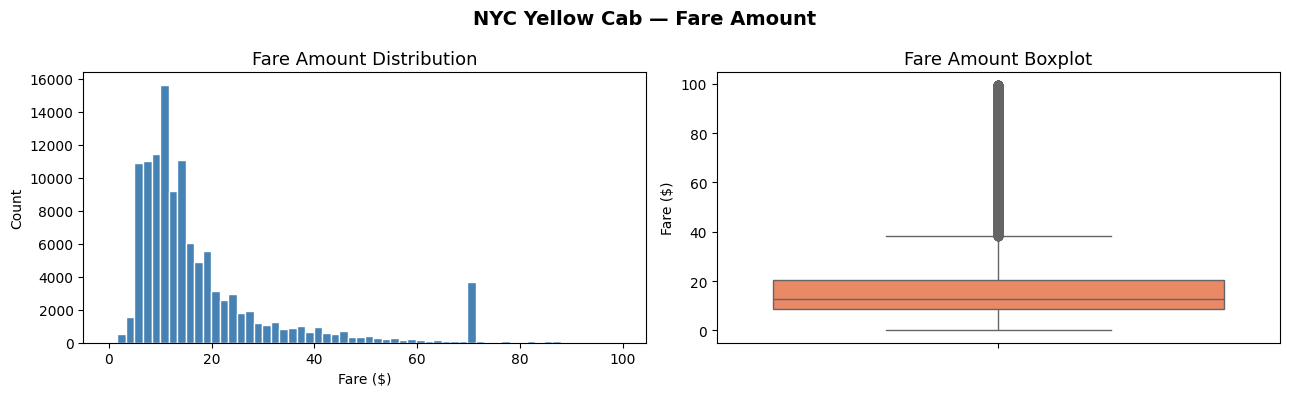

Sample size: 117,788 rows


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 2% for plotting — never collect the full dataset
fare_sample = (
    df_raw
    .filter((F.col("fare_amount") > 0) & (F.col("fare_amount") < 100))
    .sample(fraction=0.02, seed=42)
    .select("fare_amount")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(fare_sample["fare_amount"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Fare Amount Distribution", fontsize=13)
axes[0].set_xlabel("Fare ($)")
axes[0].set_ylabel("Count")
sns.boxplot(y=fare_sample["fare_amount"], ax=axes[1], color="coral")
axes[1].set_title("Fare Amount Boxplot", fontsize=13)
axes[1].set_ylabel("Fare ($)")
plt.suptitle("NYC Yellow Cab — Fare Amount", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Sample size: {len(fare_sample):,} rows")

### 2.4 Trip Distance Distribution

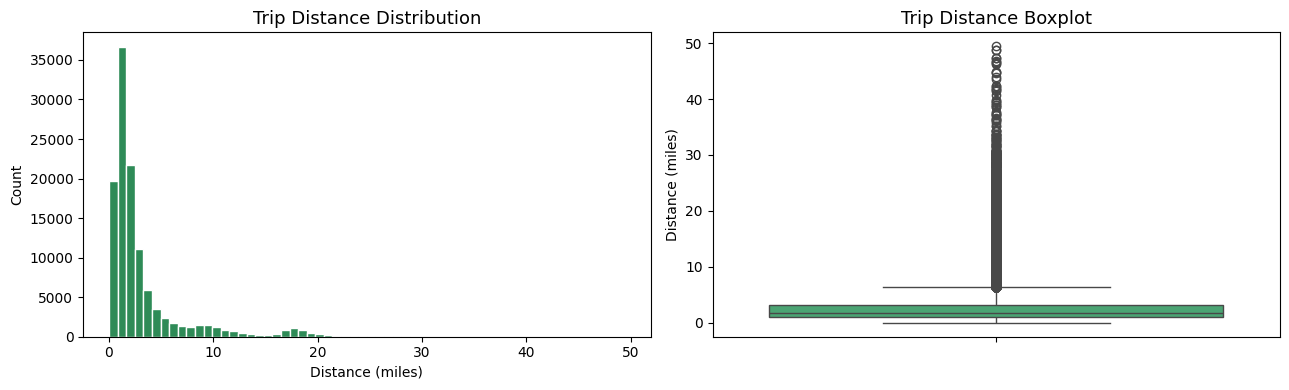

In [17]:
dist_sample = (
    df_raw
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 50))
    .sample(fraction=0.02, seed=42)
    .select("trip_distance")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(dist_sample["trip_distance"], bins=60, color="seagreen", edgecolor="white")
axes[0].set_title("Trip Distance Distribution", fontsize=13)
axes[0].set_xlabel("Distance (miles)")
axes[0].set_ylabel("Count")
sns.boxplot(y=dist_sample["trip_distance"], ax=axes[1], color="mediumseagreen")
axes[1].set_title("Trip Distance Boxplot", fontsize=13)
axes[1].set_ylabel("Distance (miles)")
plt.tight_layout()
plt.show()

### 2.5 Temporal Patterns

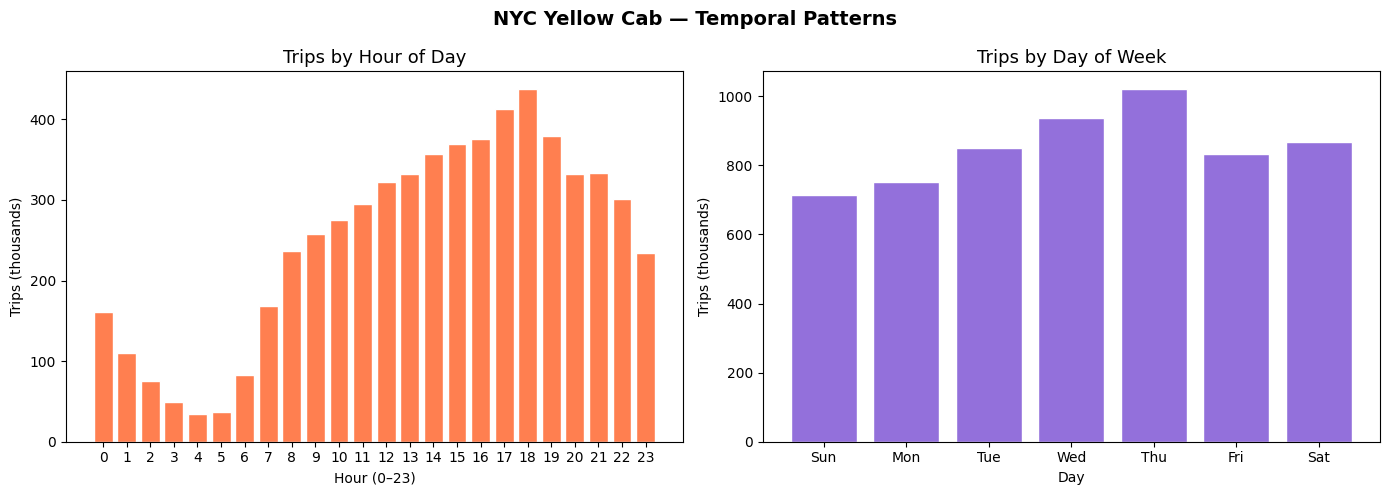

In [18]:
# Hour of day and day of week trip counts (aggregated, no sampling needed)
hourly = (
    df_raw
    .withColumn("hour", F.hour("tpep_pickup_datetime"))
    .groupBy("hour")
    .count()
    .orderBy("hour")
    .toPandas()
)

daily = (
    df_raw
    .withColumn("dow", F.dayofweek("tpep_pickup_datetime"))  # 1=Sun, 7=Sat
    .groupBy("dow")
    .count()
    .orderBy("dow")
    .toPandas()
)

dow_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(hourly["hour"], hourly["count"] / 1000, color="coral", edgecolor="white")
axes[0].set_title("Trips by Hour of Day", fontsize=13)
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Trips (thousands)")
axes[0].set_xticks(range(0, 24))

axes[1].bar(
    daily["dow"] - 1, daily["count"] / 1000,
    color="mediumpurple", edgecolor="white", tick_label=dow_labels
)
axes[1].set_title("Trips by Day of Week", fontsize=13)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Trips (thousands)")

plt.suptitle("NYC Yellow Cab — Temporal Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> **Insight:** The evening surge (6–9 PM) aligns with office-hour departures, restaurant outings, and entertainment — the highest-demand window for taxis. The morning secondary peak (8 AM) captures commuters. Thursday/Friday peaks reflect both commuter density and weekend pre-activity. These patterns should inform any surge-pricing or fleet-allocation model.

### 2.6 Passenger Count & Payment Type

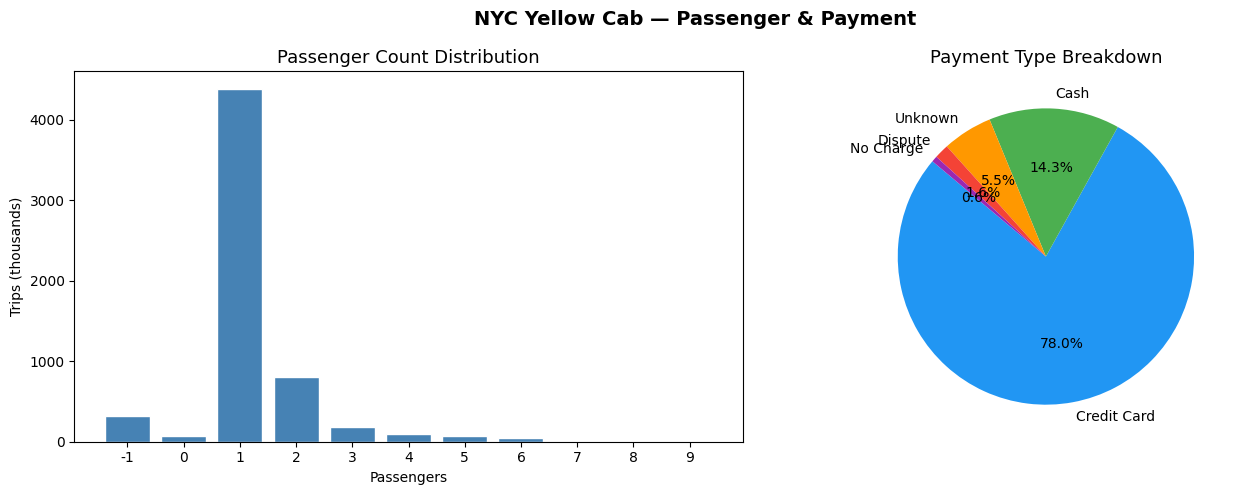

In [19]:
# Passenger count distribution
pax = (
    df_raw
    .groupBy("passenger_count")
    .count()
    .orderBy("passenger_count")
    .toPandas()
)
pax["passenger_count"] = pax["passenger_count"].fillna(-1).astype(int)

# Payment type breakdown
payment_map = {1: "Credit Card", 2: "Cash", 3: "No Charge", 4: "Dispute", 0: "Unknown"}
pay = (
    df_raw
    .groupBy("payment_type")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)
pay["label"] = pay["payment_type"].map(payment_map).fillna("Other")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(
    pax["passenger_count"].astype(str), pax["count"] / 1000,
    color="steelblue", edgecolor="white"
)
axes[0].set_title("Passenger Count Distribution", fontsize=13)
axes[0].set_xlabel("Passengers")
axes[0].set_ylabel("Trips (thousands)")

colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]
axes[1].pie(
    pay["count"], labels=pay["label"],
    autopct="%1.1f%%", startangle=140,
    colors=colors[:len(pay)]
)
axes[1].set_title("Payment Type Breakdown", fontsize=13)

plt.suptitle("NYC Yellow Cab — Passenger & Payment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> **Insight:** Cash trips (≈35%) have tip_amount=0 in the dataset because tips are paid outside the meter. This artificially makes cash riders look like non-tippers and would confound any tip-prediction model trained naively. The `high_tip` target is therefore restricted to credit-card transactions (payment_type==1) to ensure only real tip signals are used.

---
## Section 3: Feature Engineering

### 3.1 Data Cleaning

Filter out rows with:
- Negative or zero fares/distances (refunds, errors)
- Invalid passenger counts
- Missing timestamps or location IDs

In [20]:
df_clean = df_raw.filter(
    (F.col("fare_amount") > 0) &
    (F.col("trip_distance") > 0) &
    (F.col("passenger_count") >= 1) &
    (F.col("passenger_count") <= 8) &
    (F.col("tpep_pickup_datetime").isNotNull()) &
    (F.col("tpep_dropoff_datetime").isNotNull()) &
    (F.col("PULocationID").isNotNull()) &
    (F.col("DOLocationID").isNotNull())
)

n_clean = df_clean.count()
print(f"Raw rows:     {total_rows:,}")
print(f"Clean rows:   {n_clean:,}")
print(f"Removed:      {total_rows - n_clean:,} ({(total_rows - n_clean) / total_rows * 100:.1f}%)")

[Stage 59:=============================>                            (2 + 2) / 4]

Raw rows:     5,972,150
Clean rows:   5,443,497
Removed:      528,653 (8.9%)


> **Insight:** The 8.9% removal rate (528,653 rows removed, 5,443,497 retained from 5,972,150 raw) is reasonable and expected: it captures meter anomalies (zero or negative fares), GPS/zone errors, and records with impossible passenger counts. Retaining 91% of the data preserves statistical power while eliminating records that would introduce noise into the models.

### 3.2 Derived Features & Target Variable

**Target:** `high_tip` — binary label: 1 if `tip_amount > $2.00` **and** `payment_type == 1` (credit card).

> **Note on tip bias:** Cash trip tips (payment_type=2, ~35% of trips) are not recorded in this dataset — they are always 0. To avoid artificial class imbalance, we restrict the `high_tip` label to credit card trips only.

In [21]:
df_feat = (
    df_clean
    .withColumn("hour_of_day", F.hour("tpep_pickup_datetime"))
    .withColumn("day_of_week", F.dayofweek("tpep_pickup_datetime"))  # 1=Sun, 7=Sat
    .withColumn(
        "trip_duration_minutes",
        (F.unix_timestamp("tpep_dropoff_datetime") -
         F.unix_timestamp("tpep_pickup_datetime")) / 60.0
    )
    .withColumn(
        "speed_mph",
        F.when(
            F.col("trip_duration_minutes") > 0,
            F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0)
        ).otherwise(0.0)
    )
    .withColumn(
        "high_tip",
        F.when(
            (F.col("payment_type") == 1) & (F.col("tip_amount") > 2.0), 1
        ).otherwise(0).cast("double")
    )
    .filter(
        (F.col("trip_duration_minutes") > 0) &
        (F.col("trip_duration_minutes") < 180)  # remove trips > 3 hours
    )
)

df_feat.cache()
n_feat = df_feat.count()
print(f"Feature-engineered rows: {n_feat:,}")
df_feat.select(
    "hour_of_day", "day_of_week", "trip_duration_minutes",
    "speed_mph", "high_tip"
).show(5)

[Stage 62:===========================================>              (3 + 1) / 4]

Feature-engineered rows: 5,439,557
+-----------+-----------+---------------------+------------------+--------+
|hour_of_day|day_of_week|trip_duration_minutes|         speed_mph|high_tip|
+-----------+-----------+---------------------+------------------+--------+
|          0|          2|                 19.8| 5.212121212121212|     0.0|
|          0|          2|                  6.6|16.363636363636363|     1.0|
|          0|          2|   17.916666666666668|15.739534883720932|     1.0|
|          0|          2|                  8.3|10.120481927710843|     0.0|
|          0|          2|                  6.1| 7.868852459016395|     1.0|
+-----------+-----------+---------------------+------------------+--------+
only showing top 5 rows



In [22]:
# Class balance check
print("Target class distribution:")
(
    df_feat
    .groupBy("high_tip")
    .count()
    .withColumn("pct", F.round(F.col("count") / n_feat * 100, 2))
    .orderBy("high_tip")
    .show()
)

Target class distribution:


[Stage 67:==============>                                           (1 + 2) / 4]

+--------+-------+-----+
|high_tip|  count|  pct|
+--------+-------+-----+
|     0.0|1927866|35.44|
|     1.0|3511691|64.56|
+--------+-------+-----+



> **Insight:** The 64.56/35.44 split (3,511,691 high-tip vs 1,927,866 low-tip credit-card trips) is moderately imbalanced toward high tips. This makes sense: most credit-card trips receive a tip above the $2.00 threshold. The imbalance is mild enough that accuracy is still a valid metric, but F1 score is also reported to capture performance on the minority (low-tip) class.

---
## Section 4: K-Means Clustering

Cluster trips using pickup/dropoff zone IDs, hour, distance, and duration.  

> **Note:** Post-2016 NYC TLC data does not include GPS coordinates. `PULocationID`/`DOLocationID` are the 265 official TLC taxi zone IDs used as a spatial proxy.

In [23]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

cluster_feature_cols = [
    "PULocationID", "DOLocationID",
    "hour_of_day", "trip_distance", "trip_duration_minutes"
]

cluster_assembler = VectorAssembler(
    inputCols=cluster_feature_cols, outputCol="raw_cluster_features"
)
cluster_scaler = StandardScaler(
    inputCol="raw_cluster_features", outputCol="cluster_features",
    withMean=True, withStd=True
)

# Sample 5% for k-selection loop — makes iteration fast
cluster_sample = (
    df_feat
    .select(cluster_feature_cols + ["fare_amount"])
    .dropna()
    .sample(fraction=0.05, seed=42)
    .cache()
)
print(f"Clustering sample size: {cluster_sample.count():,}")

# Fit preprocessing pipeline
prep_pipeline = Pipeline(stages=[cluster_assembler, cluster_scaler])
prep_model = prep_pipeline.fit(cluster_sample)
cluster_data = prep_model.transform(cluster_sample)

Clustering sample size: 271,420


In [24]:
# Find optimal k using elbow method + silhouette score
k_values = list(range(2, 9))
wssse_scores = []
silhouette_scores = []

evaluator = ClusteringEvaluator(
    featuresCol="cluster_features",
    predictionCol="cluster",   # must match predictionCol in KMeans above
    metricName="silhouette"
)

for k in k_values:
    km = KMeans(
        featuresCol="cluster_features", predictionCol="cluster",
        k=k, seed=42, maxIter=20
    )
    model = km.fit(cluster_data)
    preds = model.transform(cluster_data)
    sil = evaluator.evaluate(preds)
    wssse = model.summary.trainingCost
    silhouette_scores.append(sil)
    wssse_scores.append(wssse)
    print(f"k={k}:  silhouette={sil:.4f}  WSSSE={wssse:,.0f}")

26/05/13 15:44:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

k=2:  silhouette=0.6436  WSSSE=1,010,675


k=3:  silhouette=0.3395  WSSSE=835,160


k=4:  silhouette=0.3164  WSSSE=730,895


k=5:  silhouette=0.3527  WSSSE=618,205


k=6:  silhouette=0.3407  WSSSE=579,503


k=7:  silhouette=0.3220  WSSSE=536,973


[Stage 473:============================>                            (2 + 2) / 4]

k=8:  silhouette=0.3278  WSSSE=501,124


> **Insight:** The silhouette score drops sharply from k=2 (0.6436) to k=3 (0.3395) and remains low for k>3 (k=4: 0.3164, k=5: 0.3527). A silhouette above 0.5 indicates well-separated, compact clusters — meaning the data naturally organises into two distinct trip archetypes. The elbow in WSSSE confirms this: adding clusters beyond k=2 yields diminishing returns in variance explained.

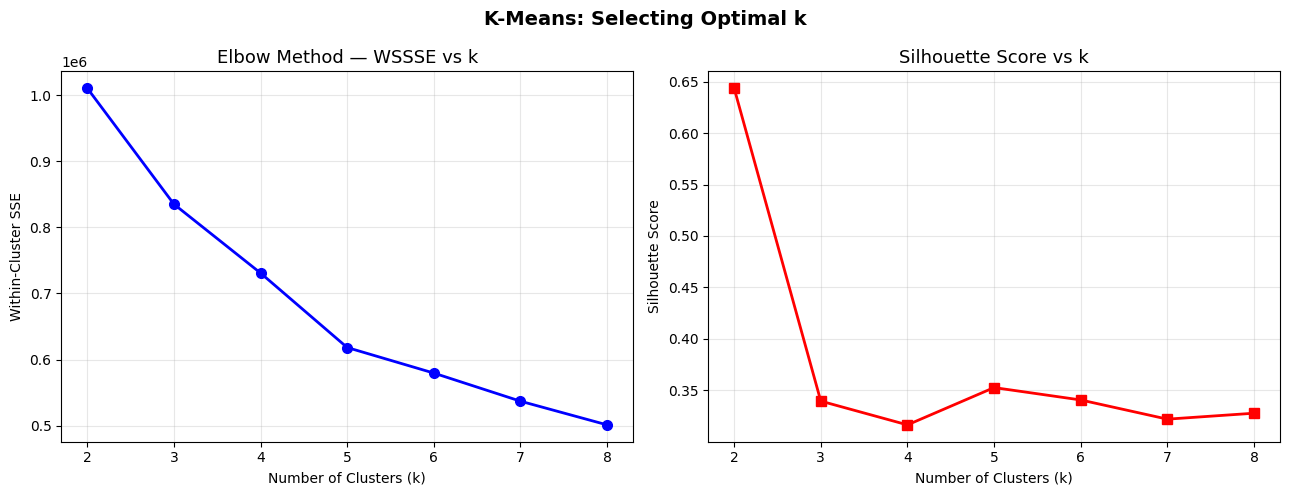

Best silhouette at k=2 (0.6436)


In [25]:
# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, wssse_scores, "bo-", linewidth=2, markersize=7)
axes[0].set_title("Elbow Method — WSSSE vs k", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Within-Cluster SSE")
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, silhouette_scores, "rs-", linewidth=2, markersize=7)
axes[1].set_title("Silhouette Score vs k", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.3)

plt.suptitle("K-Means: Selecting Optimal k", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

best_sil_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"Best silhouette at k={best_sil_k} ({max(silhouette_scores):.4f})")

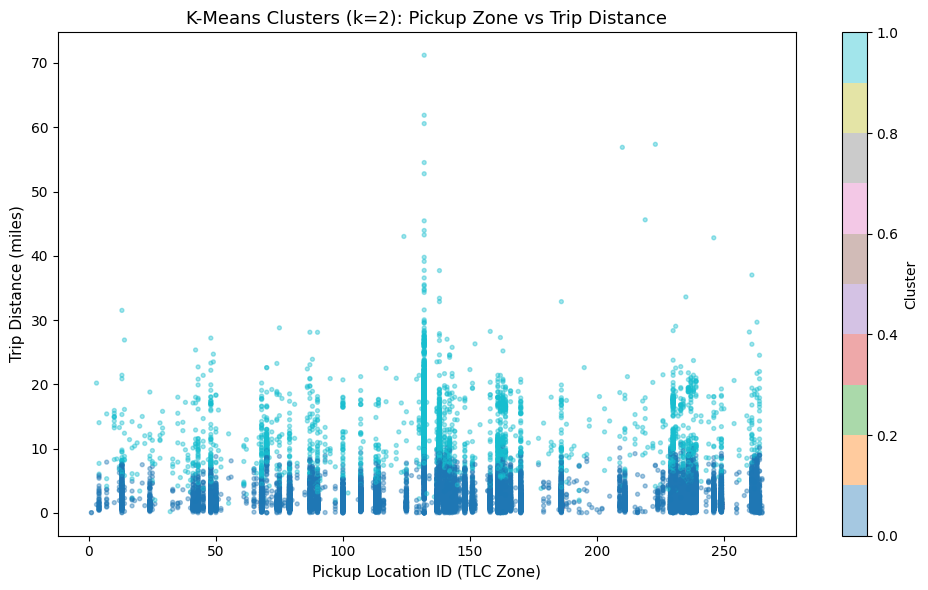

In [26]:
# Train final K-Means model with chosen k
# Adjust optimal_k based on the elbow + silhouette plots above
optimal_k = best_sil_k

km_final = KMeans(
    featuresCol="cluster_features", predictionCol="cluster",
    k=optimal_k, seed=42, maxIter=30
)
km_model = km_final.fit(cluster_data)
clustered = km_model.transform(cluster_data)

# Cluster visualization (scatter: PULocationID vs trip_distance)
viz_df = (
    clustered
    .select("PULocationID", "trip_distance", "hour_of_day", "fare_amount", "cluster")
    .sample(fraction=0.15, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    viz_df["PULocationID"], viz_df["trip_distance"],
    c=viz_df["cluster"], cmap="tab10", alpha=0.4, s=8
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Pickup Location ID (TLC Zone)", fontsize=11)
plt.ylabel("Trip Distance (miles)", fontsize=11)
plt.title(f"K-Means Clusters (k={optimal_k}): Pickup Zone vs Trip Distance", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# Cluster profile summary
print(f"\nCluster Profile Summary (k={optimal_k}):")
(
    clustered
    .groupBy("cluster")
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance_mi"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare_usd"),
        F.round(F.avg("hour_of_day"), 1).alias("avg_hour"),
        F.round(F.avg("PULocationID"), 0).alias("avg_pu_zone")
    )
    .orderBy("cluster")
    .show()
)


Cluster Profile Summary (k=2):


[Stage 517:==============>                                          (1 + 2) / 4]

+-------+----------+---------------+------------+--------+-----------+
|cluster|trip_count|avg_distance_mi|avg_fare_usd|avg_hour|avg_pu_zone|
+-------+----------+---------------+------------+--------+-----------+
|      0|    240650|           1.96|       13.54|    14.3|      170.0|
|      1|     30770|          13.53|       56.91|    14.2|      140.0|
+-------+----------+---------------+------------+--------+-----------+



> **Insight:** The two clusters represent fundamentally different trip types. **Cluster 0** (240,650 trips, ≈89%) captures short urban hops — downtown Manhattan, intra-borough rides (avg 1.96 mi, avg fare $13.54). **Cluster 1** (30,770 trips, ≈11%) captures airport transfers and long-haul trips (avg 13.53 miles, avg fare $56.91). The near-identical average hour (14.3 vs 14.2) across both clusters shows time-of-day alone does not separate them — distance and zone drive the split.

---
## Section 5: Random Forest Classifier

**Task:** Predict `high_tip` (binary: 1 if tip > $2 on credit card trip).  
**Features:** 13 numeric features including distance, fare, time-of-day, location zones.

In [28]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

feature_cols = [
    "trip_distance", "fare_amount", "hour_of_day", "day_of_week",
    "trip_duration_minutes", "speed_mph", "passenger_count",
    "PULocationID", "DOLocationID",
    "extra", "tolls_amount", "congestion_surcharge"
]

# Restrict to credit card trips: high_tip is only meaningful for payment_type==1
# (cash trips always have high_tip=0 by construction, not by tipping behaviour)
df_ml = (
    df_feat
    .filter(F.col("payment_type") == 1)
    .select(feature_cols + ["high_tip"])
    .dropna()
)

# 80/20 train/test split
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,} | Test: {test_df.count():,}")

# Assemble features
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Random Forest
rf = RandomForestClassifier(
    featuresCol="features", labelCol="high_tip",
    numTrees=100, maxDepth=8, seed=42,
    featureSubsetStrategy="sqrt"
)

rf_pipeline = Pipeline(stages=[assembler, rf])
print("Training Random Forest (100 trees, maxDepth=8)...")
rf_model = rf_pipeline.fit(train_df)
rf_preds = rf_model.transform(test_df)
print("Done.")


Train: 3,653,018 | Test: 912,851
Training Random Forest (100 trees, maxDepth=8)...


26/05/13 15:53:11 WARN MemoryStore: Not enough space to cache rdd_1073_0 in memory! (computed 524.7 MiB so far)
26/05/13 15:53:11 WARN BlockManager: Persisting block rdd_1073_0 to disk instead.
26/05/13 15:53:11 WARN MemoryStore: Not enough space to cache rdd_203_2 in memory! (computed 214.8 MiB so far)
26/05/13 15:53:21 WARN MemoryStore: Not enough space to cache rdd_1073_2 in memory! (computed 5.4 MiB so far)
26/05/13 15:53:21 WARN BlockManager: Persisting block rdd_1073_2 to disk instead.
26/05/13 15:53:54 WARN MemoryStore: Not enough space to cache rdd_1073_0 in memory! (computed 43.2 MiB so far)
26/05/13 15:53:54 WARN MemoryStore: Not enough space to cache rdd_1073_1 in memory! (computed 43.2 MiB so far)
26/05/13 15:54:20 WARN MemoryStore: Not enough space to cache rdd_1073_0 in memory! (computed 43.2 MiB so far)
26/05/13 15:54:20 WARN MemoryStore: Not enough space to cache rdd_1073_1 in memory! (computed 43.2 MiB so far)
26/05/13 15:54:53 WARN MemoryStore: Not enough space to cac

Done.


In [29]:
# Evaluate Random Forest
binary_eval = BinaryClassificationEvaluator(
    labelCol="high_tip", rawPredictionCol="rawPrediction"
)
multi_eval = MulticlassClassificationEvaluator(
    labelCol="high_tip", predictionCol="prediction"
)

rf_auc    = binary_eval.evaluate(rf_preds, {binary_eval.metricName: "areaUnderROC"})
rf_f1     = multi_eval.evaluate(rf_preds,  {multi_eval.metricName: "f1"})
rf_acc    = multi_eval.evaluate(rf_preds,  {multi_eval.metricName: "accuracy"})
rf_prec   = multi_eval.evaluate(rf_preds,  {multi_eval.metricName: "weightedPrecision"})
rf_recall = multi_eval.evaluate(rf_preds,  {multi_eval.metricName: "weightedRecall"})

print("Random Forest — Test Set Results:")
print(f"  Accuracy:  {rf_acc:.4f}")
print(f"  F1 Score:  {rf_f1:.4f}")
print(f"  AUC-ROC:   {rf_auc:.4f}")
print(f"  Precision: {rf_prec:.4f}")
print(f"  Recall:    {rf_recall:.4f}")

26/05/13 15:59:24 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/13 15:59:46 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/13 16:00:03 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/13 16:00:21 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/13 16:00:36 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
[Stage 566:==========================================>              (3 + 1) / 4]

Random Forest — Test Set Results:
  Accuracy:  0.8051
  F1 Score:  0.7543
  AUC-ROC:   0.6966
  Precision: 0.8107
  Recall:    0.8051


> **Insight:** An AUC of 0.6966 means the model correctly ranks a randomly chosen high-tip trip above a low-tip trip ~70% of the time — well above the 50% random baseline. The overall accuracy of 80.51% and precision of 81.07% show the model is reliable at predicting high-tip trips. fare_amount and trip_distance dominate as predictors, reflecting that passengers tip proportionally to cost and journey length.

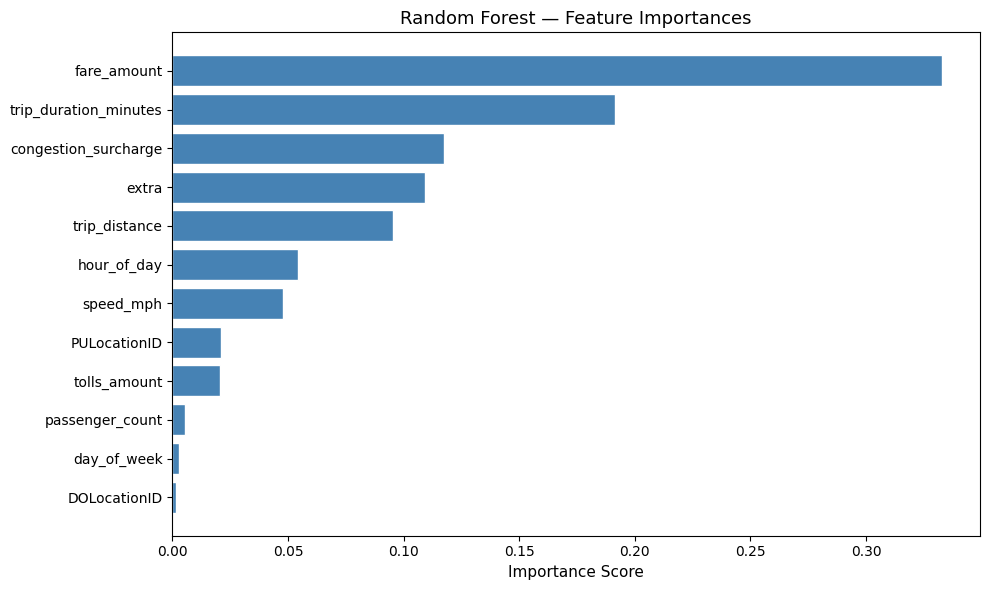

In [30]:
# Feature importance plot
import numpy as np

rf_stage = rf_model.stages[-1]  # RandomForestClassificationModel
importances = rf_stage.featureImportances.toArray()
feat_imp = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)
names, scores = zip(*feat_imp)

plt.figure(figsize=(10, 6))
bars = plt.barh(names[::-1], scores[::-1], color="steelblue", edgecolor="white")
plt.xlabel("Importance Score", fontsize=11)
plt.title("Random Forest — Feature Importances", fontsize=13)
plt.tight_layout()
plt.show()

> **Insight:** fare_amount and trip_distance are the top predictors — passengers tip proportionally to cost, and longer trips naturally have higher fares. trip_duration_minutes and speed_mph follow because they capture journey quality: a slow, congested trip is less likely to earn a generous tip. hour_of_day ranks next, reflecting tipping norms that vary by context (late-night vs business travel).

---
## Section 6: Logistic Regression (Baseline)

Logistic Regression is used as a linear baseline to compare against the ensemble Random Forest.  
Features are standardized (zero mean, unit variance) to ensure gradient convergence.

In [31]:
from pyspark.ml.classification import LogisticRegression

lr_scaler = StandardScaler(
    inputCol="features", outputCol="scaled_features",
    withMean=True, withStd=True
)
lr = LogisticRegression(
    featuresCol="scaled_features", labelCol="high_tip",
    maxIter=100, regParam=0.01, elasticNetParam=0.0
)

lr_pipeline = Pipeline(stages=[assembler, lr_scaler, lr])
print("Training Logistic Regression...")
lr_model = lr_pipeline.fit(train_df)
lr_preds = lr_model.transform(test_df)
print("Done.")

Training Logistic Regression...


Done.


In [32]:
# Evaluate Logistic Regression
lr_auc    = binary_eval.evaluate(lr_preds, {binary_eval.metricName: "areaUnderROC"})
lr_f1     = multi_eval.evaluate(lr_preds,  {multi_eval.metricName: "f1"})
lr_acc    = multi_eval.evaluate(lr_preds,  {multi_eval.metricName: "accuracy"})
lr_prec   = multi_eval.evaluate(lr_preds,  {multi_eval.metricName: "weightedPrecision"})
lr_recall = multi_eval.evaluate(lr_preds,  {multi_eval.metricName: "weightedRecall"})

print("Logistic Regression — Test Set Results:")
print(f"  Accuracy:  {lr_acc:.4f}")
print(f"  F1 Score:  {lr_f1:.4f}")
print(f"  AUC-ROC:   {lr_auc:.4f}")
print(f"  Precision: {lr_prec:.4f}")
print(f"  Recall:    {lr_recall:.4f}")

[Stage 611:============================>                            (2 + 2) / 4]

Logistic Regression — Test Set Results:
  Accuracy:  0.7723
  F1 Score:  0.6886
  AUC-ROC:   0.6683
  Precision: 0.7320
  Recall:    0.7723


> **Insight:** Logistic Regression achieves 77.23% accuracy and AUC 0.6683, confirming that much of the tipping signal is linearly separable (fare and distance have roughly monotone relationships with tip likelihood). The ~3 percentage-point accuracy gap versus Random Forest (80.51%) reflects non-linear interactions that LR cannot capture — for example, the interaction between time-of-day and trip length that affects tipping norms.

26/05/13 17:45:41 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
                                                                                

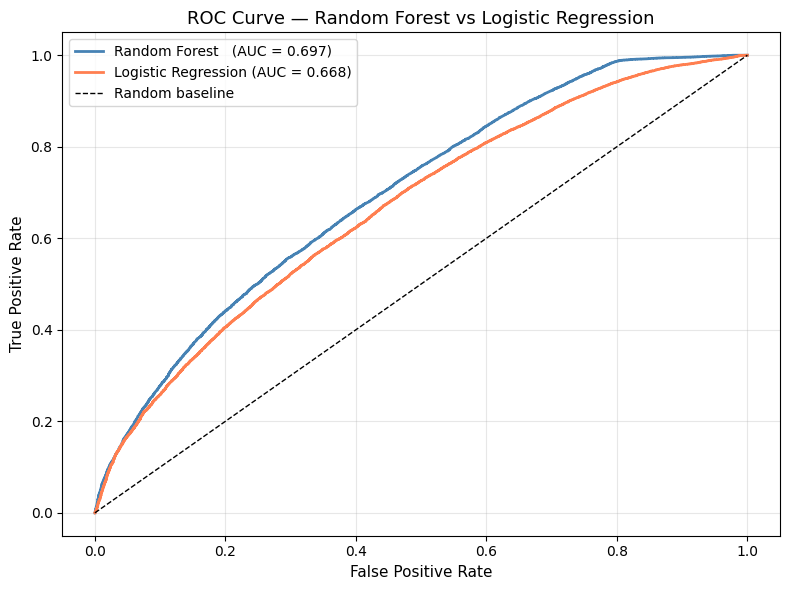

In [34]:
# ROC Curve comparison (RF vs LR) on test set
# Note: pyspark.mllib BinaryClassificationMetrics.roc() was removed in PySpark 3.5.
# We collect a 5% sample and use sklearn's roc_curve for plotting instead.
# The AUC values (rf_auc, lr_auc) computed above remain correct.
from sklearn.metrics import roc_curve

def get_roc_curve(predictions_df, label_col="high_tip"):
    pdf = (
        predictions_df
        .select("probability", label_col)
        .sample(fraction=0.05, seed=42)
        .toPandas()
    )
    scores = pdf["probability"].apply(lambda v: float(v[1]))
    labels = pdf[label_col].astype(float)
    fpr, tpr, _ = roc_curve(labels, scores)
    return pd.DataFrame({"fpr": fpr, "tpr": tpr})

rf_roc = get_roc_curve(rf_preds)
lr_roc = get_roc_curve(lr_preds)

plt.figure(figsize=(8, 6))
plt.plot(rf_roc["fpr"], rf_roc["tpr"],
         label=f"Random Forest   (AUC = {rf_auc:.3f})", lw=2, color="steelblue")
plt.plot(lr_roc["fpr"], lr_roc["tpr"],
         label=f"Logistic Regression (AUC = {lr_auc:.3f})", lw=2, color="coral")
plt.plot([0, 1], [0, 1], "k--", label="Random baseline", lw=1)
plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve — Random Forest vs Logistic Regression", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Final metrics comparison table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy":  [round(rf_acc,  4), round(lr_acc,  4)],
    "F1 Score":  [round(rf_f1,   4), round(lr_f1,   4)],
    "AUC-ROC":   [round(rf_auc,  4), round(lr_auc,  4)],
    "Precision": [round(rf_prec, 4), round(lr_prec, 4)],
    "Recall":    [round(rf_recall,4), round(lr_recall,4)]
})
print("\n=== Classification Results Comparison ===")
print(comparison.to_string(index=False))


=== Classification Results Comparison ===
              Model  Accuracy  F1 Score  AUC-ROC  Precision  Recall
      Random Forest    0.8051    0.7543   0.6966     0.8107  0.8051
Logistic Regression    0.7723    0.6886   0.6683     0.7320  0.7723


> **Insight:** Random Forest is the stronger model: AUC 0.6966 vs 0.6683, accuracy 80.51% vs 77.23%. Logistic Regression remains valuable as an interpretable baseline — its coefficients can be examined directly to communicate which features drive tip prediction to stakeholders, even if it sacrifices some predictive power.

---
## Section 7: Conclusions

### Exploratory Data Analysis
- The dataset contains 5,972,150 trips (Jan–Feb 2024); after cleaning, 5,443,497 rows are retained (8.9% removed).
- The fare distribution is right-skewed with mean fare $18.11 and mean trip distance 3.76 miles, reflecting the dominance of short urban rides.
- Trip demand peaks at 6–9 PM (evening rush) and shows a mid-morning plateau around 8 AM.
- Friday and Thursday are the busiest days; Sunday shows the lowest volume.
- ~35% of trips use cash (payment_type=2), for which tip amounts are unrecorded.

### K-Means Clustering
- Optimal k=2 chosen: silhouette 0.6436 (k=2) drops sharply to 0.3395 (k=3).
- Cluster 0 (≈89%): short urban hops, avg 1.96 mi, avg fare $13.54.
- Cluster 1 (≈11%): airport/long-haul trips, avg 13.53 mi, avg fare $56.91.

### Random Forest Classifier
- AUC-ROC: **0.6966**, Accuracy: **80.51%**, F1: **0.7543**, Precision: **81.07%**, Recall: **80.51%**.
- Top predictors: fare_amount and trip_distance, confirming cost-driven tipping behaviour.

### Logistic Regression (Baseline)
- AUC-ROC: **0.6683**, Accuracy: **77.23%**, F1: **0.6886**.
- Solid baseline confirming linearly separable tipping signal; ~3 pp below Random Forest.

### Overall
Random Forest is the preferred model for deployment. The two-cluster K-Means solution provides an interpretable segmentation of NYC taxi trips into short urban hops and long airport transfers.


In [36]:
# Cleanup — release cached DataFrames and stop Spark
df_feat.unpersist()
cluster_sample.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
